In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

from multicam_bolshoi.mah import get_mah
mah_data = get_mah('../data/processed/bolshoi_m12', cutoff_missing=0.05, cutoff_particle=0.05)


# extract mah of all haloes 
ma = mah_data['ma_peak']
ma.shape # the first dimension is the number of haloes, the second is the number of snapshots.

scales = mah_data['scales']
scales.shape


cat = mah_data['cat'] # astropy table with present-day halo properties
cvir = cat['cvir']
xoff = cat['x0']
t_over_u = cat['t/|u|']
spin = cat['spin_bullock']
c_to_a = cat['c_to_a']

cvir.shape, spin.shape # 1 dimensional quantities, one per halo

((10000,), (10000,))

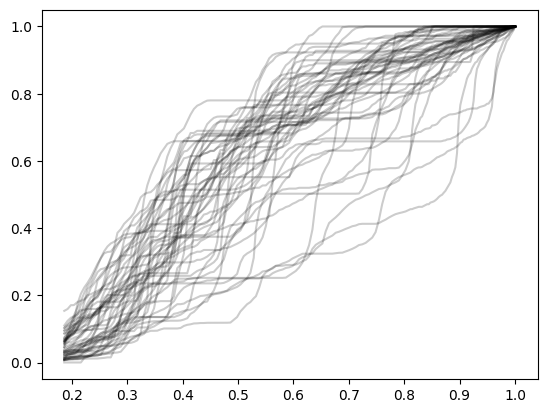

In [60]:
# MAH examples 
for _ in range(50):
    indx= np.random.randint(len(ma))
    plt.plot(scales, ma[indx], color='k', alpha=0.2)

(array([0.000e+00, 4.700e+01, 7.900e+01, 1.370e+02, 2.170e+02, 3.050e+02,
        3.960e+02, 5.480e+02, 7.530e+02, 8.640e+02, 1.004e+03, 1.093e+03,
        9.630e+02, 9.650e+02, 7.620e+02, 5.860e+02, 4.090e+02, 2.930e+02,
        2.090e+02, 1.030e+02, 8.300e+01, 3.600e+01, 2.600e+01, 2.600e+01,
        1.300e+01, 1.200e+01, 1.200e+01, 9.000e+00, 5.000e+00, 8.000e+00,
        5.000e+00, 1.000e+00, 2.000e+00, 3.000e+00, 1.000e+00, 1.000e+00,
        2.000e+00, 2.000e+00, 3.000e+00, 3.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 2.000e+00, 0.000e+00, 1.000e+00, 2.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00, 0.000e+00]),
 array([ 0.        ,  0.78431373,  1.56862745,  2.35294118,  3.1372549 ,
         3.92156863,  4.70588235,  5.49019608,  6.2745098 ,  7.05882353,
         7.84313725,  8.62745098,  9.41176471, 10.19607843, 10.98039216,
        11.76470588, 12.54901961, 13.33333333, 14.11764706, 14.90196078,
        15.68627451, 16.47058824, 17.25490196, 18.03921569, 18.82352941,


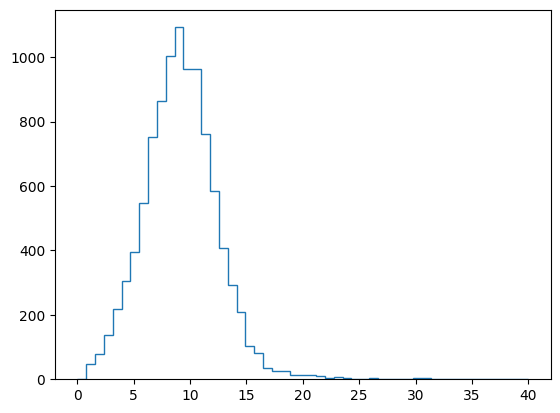

In [56]:
# concentration histogram 
plt.hist(cvir, bins=51, histtype='step', range=(0, 40))

In [ ]:
from sklearn.preprocessing import QuantileTransformer
from sklearn import linear_model


def _gauss_transform(x: np.ndarray):
    """Transform x to be (marginally) gaussian."""
    assert x.ndim == 2
    qt = QuantileTransformer(n_quantiles=len(x), output_distribution="normal", subsample=None)
    qt.fit(x)
    return qt.transform(x), qt


def multicam(x, x_train, y_train):
    assert x.ndim == x_train.ndim == y_train.ndim == 2
    xt_gauss, qtx = _gauss_transform(x_train)
    yt_gauss, qty = _gauss_transform(y_train)
    reg = linear_model.LinearRegression()
    reg.fit(xt_gauss, yt_gauss)

    x_gauss = qtx.transform(x)
    y_not_gauss = reg.predict(x_gauss)

    y_pred_train = reg.predict(xt_gauss)
    _, qtp = _gauss_transform(y_pred_train)
    y_gauss = qtp.transform(y_not_gauss)

    # invert y_gauss to data space based on gaussianized y_train.
    y_pred = qty.inverse_transform(y_gauss)
    return y_pred, y_gauss, y_not_gauss, x_gauss

In [7]:
from scipy.stats import norm, rankdata

def qt_uniform(x, axis: int = 0, method="ordinal"):  # default in rankdata = 'average'
    """Transform array to a uniform distribution based on ranks."""
    ranks = rankdata(x, axis=axis, method=method)
    return ranks / (ranks.shape[axis] + 1)  # excludes 0 and 1


def qt_gauss(x, axis: int = 0, method="ordinal"):
    """Transform array to a Gaussian distribution based on ranks."""
    u = qt_uniform(x, axis=axis, method=method)
    return norm.ppf(u)


def qt_gauss_base(x, x_base):
    """Gaussinize input based on another dataset."""
    # always assume second dimension is n_features.
    assert x.ndim == 2 and x_base.ndim == 2
    assert x.shape[1] == x_base.shape[1]
    n_features = x.shape[1]
    x_gauss = np.zeros_like(x) * np.nan
    for jj in range(n_features):
        x_jj = x[:, jj]
        xb_jj = np.sort(x_base[:, jj])  # required for np.interp
        xb_gauss_jj = qt_gauss(xb_jj, method="ordinal")
        x_gauss[:, jj] = np.interp(x_jj, xb_jj, xb_gauss_jj)
    return x_gauss


def qt_inverse_gauss_base(x_gauss, x_base):
    assert x_gauss.ndim == 2 and x_base.ndim == 2
    assert x_gauss.shape[1] == x_base.shape[1]
    n_features = x_gauss.shape[1]
    x_out = np.zeros_like(x_gauss) * np.nan
    for jj in range(n_features):
        xg_jj = x_gauss[:, jj]
        xb_jj = np.sort(x_base[:, jj])  # required for np.interp
        xb_gauss_jj = qt_gauss(xb_jj, method="ordinal")
        x_out[:, jj] = np.interp(xg_jj, xb_gauss_jj, xb_jj)
    return x_out

def new_multicam(x, x_train, y_train):
    assert x.ndim == x_train.ndim == y_train.ndim == 2
    xt_gauss = qt_gauss(x_train, axis=0)
    yt_gauss = qt_gauss(y_train, axis=0)

    reg = linear_model.LinearRegression()
    reg.fit(xt_gauss, yt_gauss)

    x_gauss = qt_gauss_base(x, x_train)
    y_not_gauss = reg.predict(x_gauss)

    y_pred_train = reg.predict(xt_gauss)
    y_gauss = qt_gauss_base(y_not_gauss, y_pred_train)

    # invert y_gauss to data space based on gaussianized y_train.
    y_pred = qt_inverse_gauss_base(y_gauss, y_train) 
    return y_pred, y_gauss, y_not_gauss, x_gauss


In [ ]:
from multicam.train import _get_tt_indices

n_haloes = len(cat)
train_idx, test_idx = _get_tt_indices(n_haloes, test_ratio=0.25)

# Only one feature (low repeats)

In [21]:
ma_train = ma[train_idx]
ma_test = ma[test_idx]
cvir_train = cvir[train_idx].reshape(-1, 1)
cvir_test = cvir[test_idx].reshape(-1, 1)

an_train = ma_train[:, 41, None]
an_test = ma_test[:, 41, None]

an_train.shape, cvir_train.shape

((7500, 1), (7500, 1))

In [38]:
# number of repeats
np.sum(ma[:, 41] == 1.)

np.int64(2)

In [22]:
yp1, yg1, yng1, xg1 = multicam(an_test, an_train, cvir_train)
yp2, yg2, yng2, xg2 = new_multicam(an_test, an_train, cvir_train)

In [23]:
xg2.shape

(2500, 1)

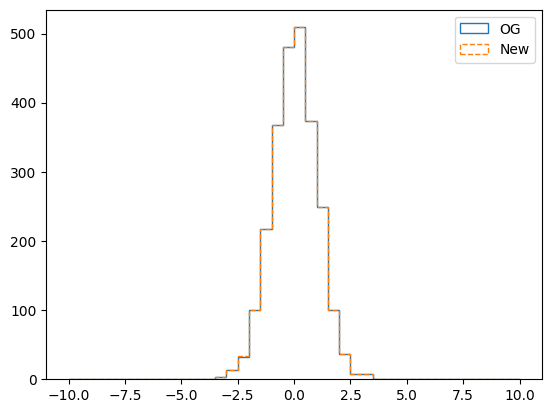

In [24]:
bins = np.linspace(-10, 10, 41)
_, bins, _ = plt.hist(xg1, bins=bins, histtype='step', label='OG')
plt.hist(xg2, bins=bins, histtype='step', ls='--', label='New');
plt.legend()

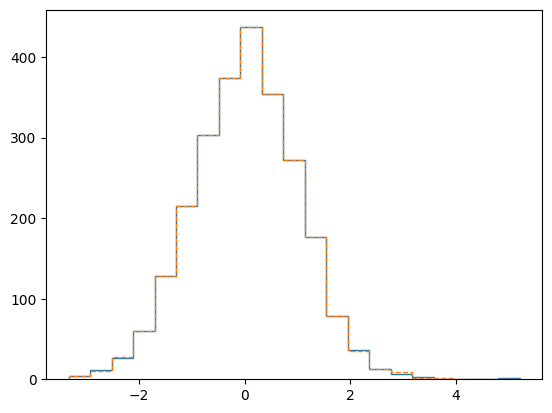

In [25]:
_, bins, _ = plt.hist(yg1, bins=21, histtype='step')
plt.hist(yg2, bins=bins, histtype='step', ls='--');

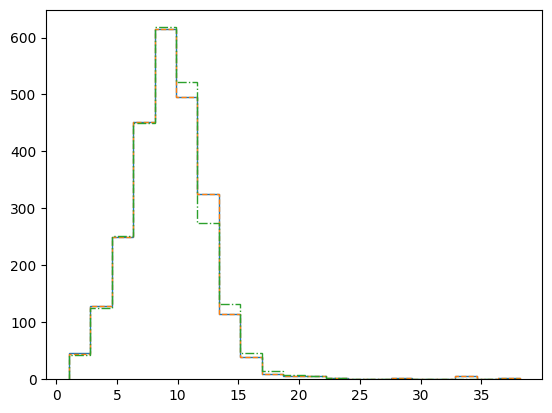

In [26]:
_, bins, _ = plt.hist(yp1, bins=21, histtype='step')
plt.hist(yp2, bins=bins, histtype='step', ls='--');
plt.hist(cvir_test, bins=bins, histtype='step', ls='-.');

In [27]:
spearmanr(yp1, cvir_test), spearmanr(yp2, cvir_test)

(SignificanceResult(statistic=np.float64(0.6753842684488305), pvalue=np.float64(0.0)),
 SignificanceResult(statistic=np.float64(0.6753842684488305), pvalue=np.float64(0.0)))

# Only 1 feature (many repeats)

In [ ]:
ma_train = ma[train_idx]
ma_test = ma[test_idx]
cvir_train = cvir[train_idx].reshape(-1, 1)
cvir_test = cvir[test_idx].reshape(-1, 1)

an_train = ma_train[:, 130, None]
an_test = ma_test[:, 130, None]

an_train.shape, cvir_train.shape

In [ ]:
# number of repeats
np.sum(ma[:, 130] == 1.)

np.int64(2229)

In [33]:
yp1, yg1, yng1, xg1 = multicam(an_test, an_train, cvir_train)
yp2, yg2, yng2, xg2 = new_multicam(an_test, an_train, cvir_train)

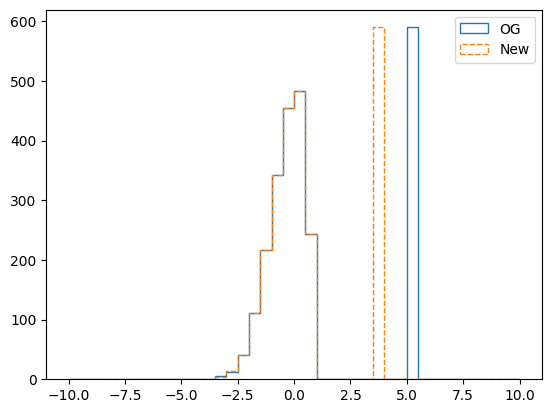

In [34]:
bins = np.linspace(-10, 10, 41)
_, bins, _ = plt.hist(xg1, bins=bins, histtype='step', label='OG')
plt.hist(xg2, bins=bins, histtype='step', ls='--', label='New');
plt.legend()

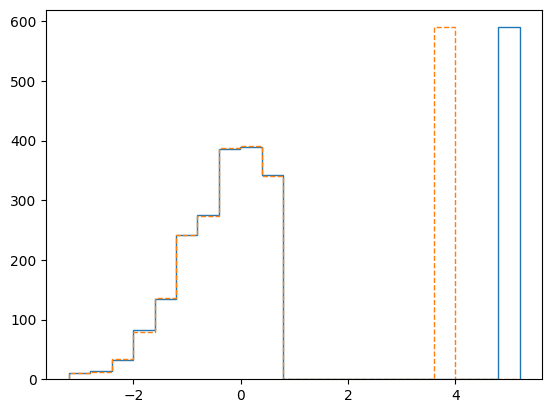

In [35]:
_, bins, _ = plt.hist(yg1, bins=21, histtype='step')
plt.hist(yg2, bins=bins, histtype='step', ls='--');

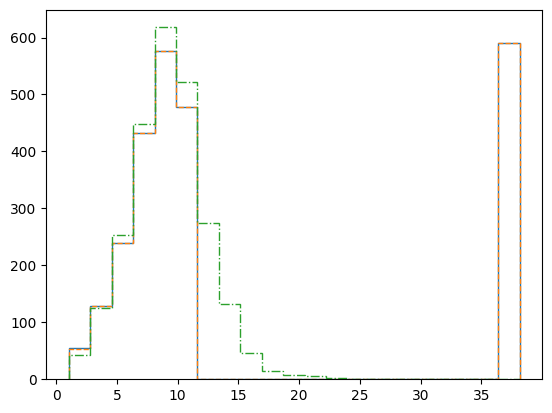

In [36]:
_, bins, _ = plt.hist(yp1, bins=21, histtype='step')
plt.hist(yp2, bins=bins, histtype='step', ls='--');
plt.hist(cvir_test, bins=bins, histtype='step', ls='-.');

In [37]:
spearmanr(yp1, cvir_test), spearmanr(yp2, cvir_test)

(SignificanceResult(statistic=np.float64(0.15959222067391104), pvalue=np.float64(9.978826427623792e-16)),
 SignificanceResult(statistic=np.float64(0.15959222067391104), pvalue=np.float64(9.978826427623792e-16)))

# All features

In [39]:
ma_train = ma[train_idx]
ma_test = ma[test_idx]
cvir_train = cvir[train_idx].reshape(-1, 1)
cvir_test = cvir[test_idx].reshape(-1, 1)


In [40]:
yp1, yg1, yng1, xg1 = multicam(ma_test, ma_train, cvir_train)
yp2, yg2, yng2, xg2 = new_multicam(ma_test, ma_train, cvir_train)

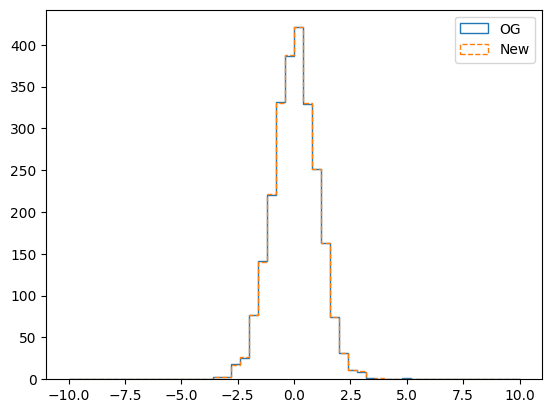

In [50]:
idx = 40
bins = np.linspace(-10, 10, 51)
_, bins, _ = plt.hist(xg1[:, idx], bins=bins, histtype='step', label='OG')
plt.hist(xg2[:, idx], bins=bins, histtype='step', ls='--', label='New');
plt.legend()

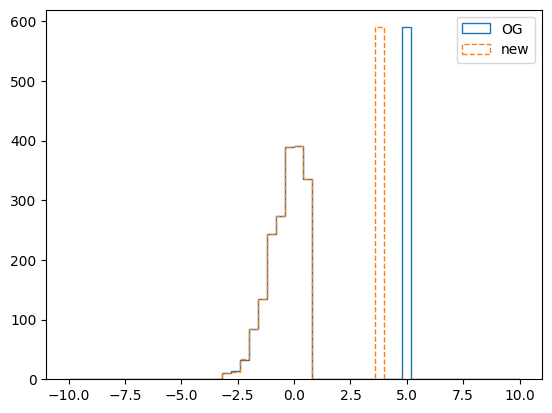

In [49]:
idx = 130
bins = np.linspace(-10, 10, 51)
_, bins, _ = plt.hist(xg1[:, idx], bins=bins, histtype='step', label='OG')
plt.hist(xg2[:, idx], bins=bins, histtype='step', ls='--', label='new');
plt.legend()

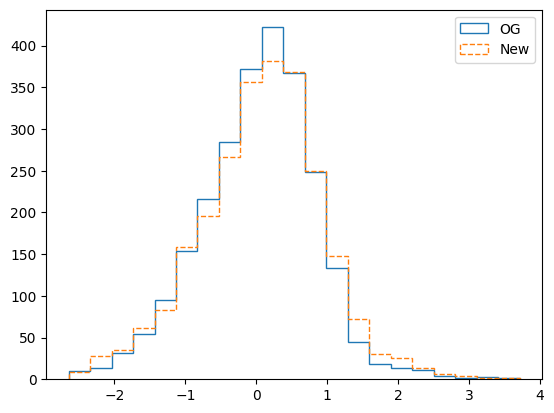

In [53]:
_, bins, _ = plt.hist(yng1, bins=21, histtype='step', label="OG")
plt.hist(yng2, bins=bins, histtype='step', ls='--', label="New");
plt.legend()

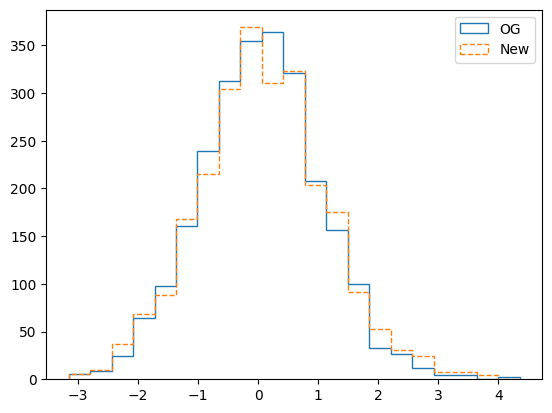

In [54]:
_, bins, _ = plt.hist(yg1, bins=21, histtype='step', label="OG")
plt.hist(yg2, bins=bins, histtype='step', ls='--', label="New");
plt.legend()

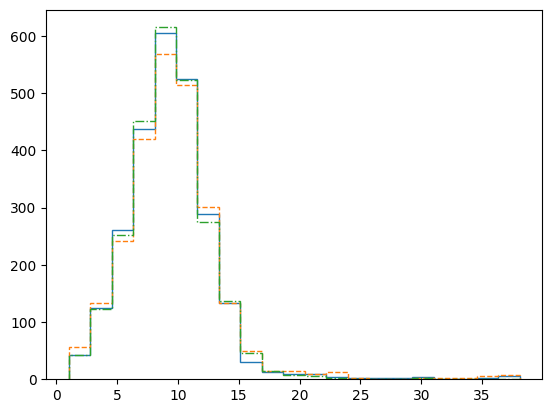

In [46]:
_, bins, _ = plt.hist(yp1, bins=21, histtype='step')
plt.hist(yp2, bins=bins, histtype='step', ls='--');
plt.hist(cvir_test, bins=bins, histtype='step', ls='-.');

In [47]:
spearmanr(yp1, cvir_test), spearmanr(yp2, cvir_test)

(SignificanceResult(statistic=np.float64(0.7758868864028721), pvalue=np.float64(0.0)),
 SignificanceResult(statistic=np.float64(0.718743493934944), pvalue=np.float64(0.0)))